<h1 align="center"><strong>CÁC MÔ HÌNH MACHINE LEARNING </strong></h1>

Huấn luyện và so sánh 7 mô hình Machine learning trên 59 engineered features.  
Mỗi mô hình được đánh giá bằng Accuracy, F1-weighted và F1-macro.

**Models:** KNN · Naive Bayes · Decision Tree · SVM · Logistic Regression · MLP · Random Forest

## **1. Setup**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv ('../final_dataset_with_all_features_v3.1.csv')
df_tab = df.drop (columns=['url', 'type', 'domain', 'scan_date'])

X=df_tab.drop (columns = ['label'])
y=df_tab['label']
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size = 0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform (X_train), columns = X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test),columns = X.columns)


## **2. Hàm Đánh Giá Chung**


In [4]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report)
def evaluate_model (name, y_test, y_pred):
    acc = accuracy_score (y_test, y_pred)
    f1_weighted = f1_score(y_test, y_pred, average= 'weighted', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    prec_macro = precision_score (y_test, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_test,y_pred, average='macro', zero_division=0)

    print(f"\n{'='*45}")
    print(f"{name}")
    print(f"{'='*45}")
    print(f"Accuracy     : {acc*100:.2f}%")
    print(f"F1-weighted  : {f1_weighted*100:.2f}% ")
    print(f"F1-macro     : {f1_macro*100:.2f}%")
    print(f"Precision-macro: {prec_macro*100:.2f}%")
    print(f"Recall-macro   : {rec_macro*100:.2f}%")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Benign','Defacement','Phishing','Malware'], zero_division=0)}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap (cm, annot=True, fmt ='d', cmap = 'Blues',
                 xticklabels = ['Benign', 'Defacement', 'Phishing', 'Malware'],
                 yticklabels = ['Benign', 'Defacement', 'Phishing', 'Malware'])
    plt.title (f'Confusion Matrix - {name}')
    plt.ylabel ('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    return {'Model': name, 'Accuracy': acc, 'F1-weighted': f1_weighted,
            'F1-macro': f1_macro, 'Precision-macro': prec_macro, 'Recall-macro': rec_macro}

result =[]

## **3. KNN**


KNN
Accuracy     : 91.48%
F1-weighted  : 91.14% 
F1-macro     : 88.56%
Precision-macro: 90.26%
Recall-macro   : 87.27%

              precision    recall  f1-score   support

      Benign       0.93      0.96      0.95     85621
  Defacement       0.95      0.98      0.96     19292
    Phishing       0.77      0.63      0.69     18822
     Malware       0.97      0.92      0.94      6504

    accuracy                           0.91    130239
   macro avg       0.90      0.87      0.89    130239
weighted avg       0.91      0.91      0.91    130239



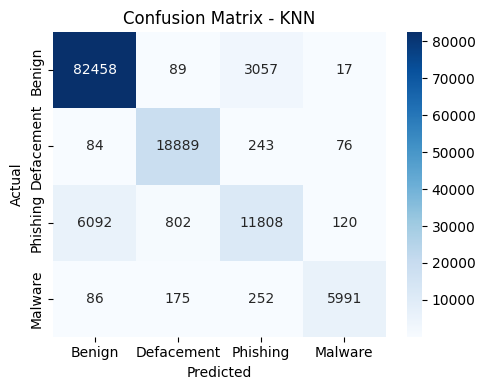

In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
result.append(evaluate_model('KNN', y_test, y_pred_knn))

## 4. Naive Bayes


Naive Bayes
Accuracy     : 80.48%
F1-weighted  : 76.16% 
F1-macro     : 64.84%
Precision-macro: 73.03%
Recall-macro   : 68.73%

              precision    recall  f1-score   support

      Benign       0.84      0.93      0.88     85621
  Defacement       0.72      0.98      0.83     19292
    Phishing       0.67      0.09      0.16     18822
     Malware       0.70      0.75      0.72      6504

    accuracy                           0.80    130239
   macro avg       0.73      0.69      0.65    130239
weighted avg       0.79      0.80      0.76    130239



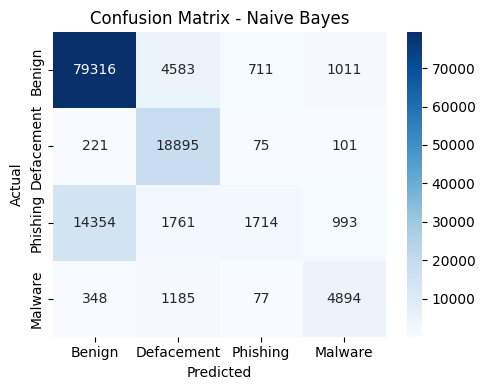

In [6]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit (X_train, y_train)
y_pred_nb = nb.predict(X_test)
result.append(evaluate_model('Naive Bayes', y_test, y_pred_nb))

## **5. Decision Tree**


Decision Tree
Accuracy     : 87.27%
F1-weighted  : 84.87% 
F1-macro     : 78.38%
Precision-macro: 88.36%
Recall-macro   : 75.67%

              precision    recall  f1-score   support

      Benign       0.87      0.99      0.93     85621
  Defacement       0.88      0.96      0.92     19292
    Phishing       0.82      0.28      0.42     18822
     Malware       0.96      0.80      0.87      6504

    accuracy                           0.87    130239
   macro avg       0.88      0.76      0.78    130239
weighted avg       0.87      0.87      0.85    130239



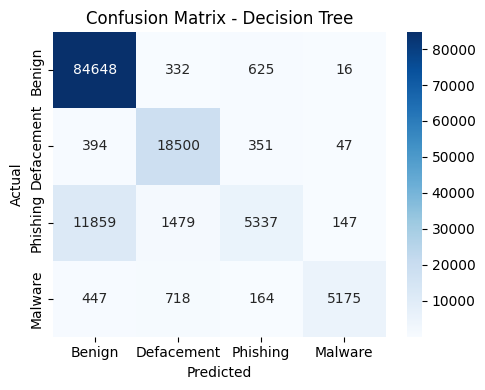

In [7]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit (X_train, y_train)
y_pred_dt = dt.predict(X_test)
result.append (evaluate_model('Decision Tree', y_test, y_pred_dt))

## **6. SVM**


SVM
Accuracy     : 36.77%
F1-weighted  : 38.45% 
F1-macro     : 39.68%
Precision-macro: 60.81%
Recall-macro   : 48.30%

              precision    recall  f1-score   support

      Benign       0.95      0.27      0.42     85621
  Defacement       0.20      0.98      0.33     19292
    Phishing       0.52      0.12      0.20     18822
     Malware       0.76      0.56      0.64      6504

    accuracy                           0.37    130239
   macro avg       0.61      0.48      0.40    130239
weighted avg       0.77      0.37      0.38    130239



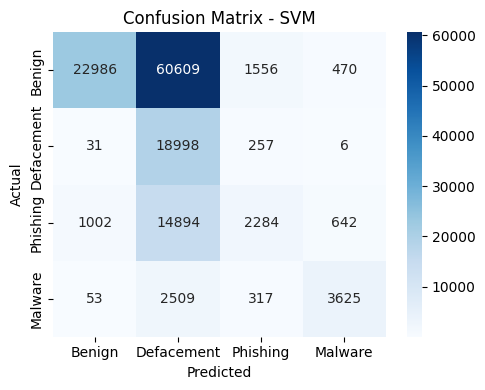

In [9]:
from sklearn.svm import LinearSVC
svm_model = LinearSVC(random_state=42, max_iter=1000)
svm_model.fit (X_train, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
result.append(evaluate_model('SVM', y_test, y_pred_svm))

## **7. Logistic Regression**


Logistic Regression
Accuracy     : 84.78%
F1-weighted  : 80.90% 
F1-macro     : 71.56%
Precision-macro: 83.33%
Recall-macro   : 70.71%

              precision    recall  f1-score   support

      Benign       0.85      0.99      0.91     85621
  Defacement       0.86      0.96      0.90     19292
    Phishing       0.76      0.15      0.25     18822
     Malware       0.87      0.74      0.80      6504

    accuracy                           0.85    130239
   macro avg       0.83      0.71      0.72    130239
weighted avg       0.84      0.85      0.81    130239



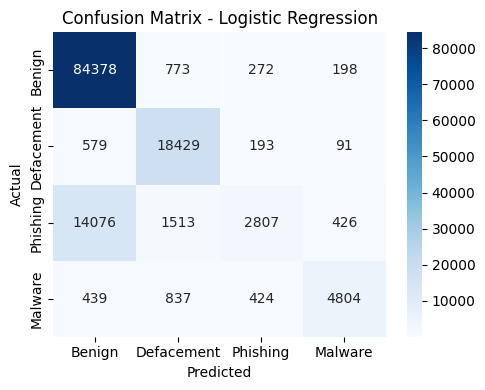

In [11]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit (X_train_scaled, y_train)
y_pred_log_reg = log_reg.predict(X_test_scaled)
result.append(evaluate_model('Logistic Regression', y_test, y_pred_log_reg))

## **8. Neural Network (MLP)**


Neural Network (MLP)
Accuracy     : 92.39%
F1-weighted  : 91.88% 
F1-macro     : 89.15%
Precision-macro: 92.41%
Recall-macro   : 87.02%

              precision    recall  f1-score   support

      Benign       0.93      0.98      0.95     85621
  Defacement       0.95      0.98      0.97     19292
    Phishing       0.85      0.61      0.71     18822
     Malware       0.97      0.91      0.94      6504

    accuracy                           0.92    130239
   macro avg       0.92      0.87      0.89    130239
weighted avg       0.92      0.92      0.92    130239



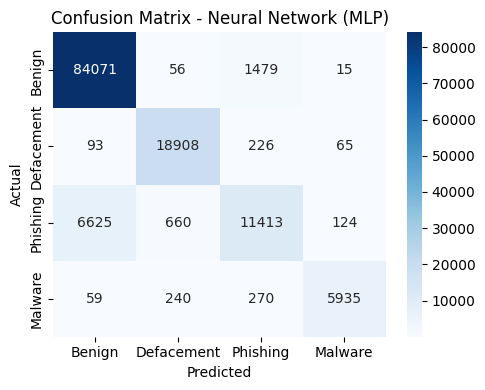

In [12]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000,
                    random_state=42, early_stopping=True)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)
result.append(evaluate_model('Neural Network (MLP)', y_test, y_pred_mlp))

## **9. Random Forest**


Random Forest
Accuracy     : 92.63%
F1-weighted  : 92.26% 
F1-macro     : 90.20%
Precision-macro: 92.41%
Recall-macro   : 88.59%

              precision    recall  f1-score   support

      Benign       0.93      0.97      0.95     85621
  Defacement       0.96      0.98      0.97     19292
    Phishing       0.82      0.64      0.72     18822
     Malware       0.98      0.94      0.96      6504

    accuracy                           0.93    130239
   macro avg       0.92      0.89      0.90    130239
weighted avg       0.92      0.93      0.92    130239



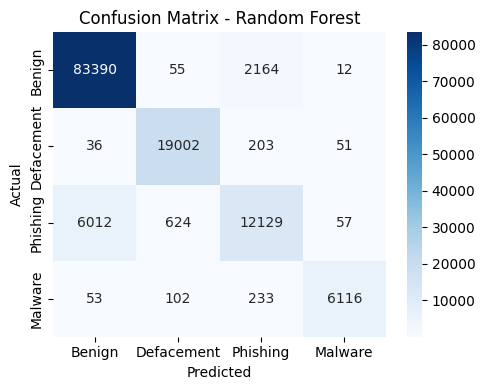

In [14]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
result.append(evaluate_model('Random Forest', y_test, y_pred_rf))


## **10. Adaboost**


AdaBoost
Accuracy     : 78.52%
F1-weighted  : 75.89% 
F1-macro     : 59.89%
Precision-macro: 61.38%
Recall-macro   : 61.67%

              precision    recall  f1-score   support

      Benign       0.85      0.94      0.89     85621
  Defacement       0.80      0.77      0.78     19292
    Phishing       0.37      0.15      0.21     18822
     Malware       0.44      0.61      0.51      6504

    accuracy                           0.79    130239
   macro avg       0.61      0.62      0.60    130239
weighted avg       0.75      0.79      0.76    130239



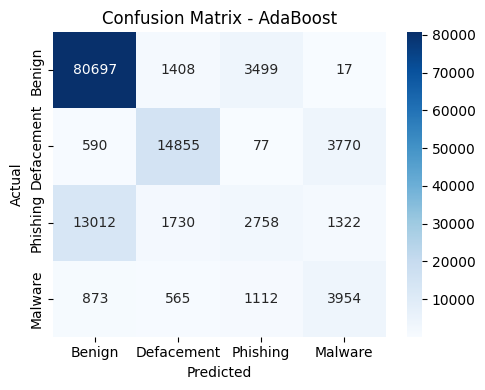

In [15]:
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier(n_estimators= 100, random_state=42)
ada.fit (X_train, y_train)
y_pred_ada= ada.predict(X_test)
result.append(evaluate_model('AdaBoost', y_test, y_pred_ada))

## **11. Gradient Boosting**


Gradient Boosting
Accuracy     : 86.92%
F1-weighted  : 83.96% 
F1-macro     : 77.19%
Precision-macro: 88.68%
Recall-macro   : 75.26%

              precision    recall  f1-score   support

      Benign       0.86      0.99      0.92     85621
  Defacement       0.89      0.97      0.93     19292
    Phishing       0.86      0.23      0.36     18822
     Malware       0.94      0.82      0.88      6504

    accuracy                           0.87    130239
   macro avg       0.89      0.75      0.77    130239
weighted avg       0.87      0.87      0.84    130239



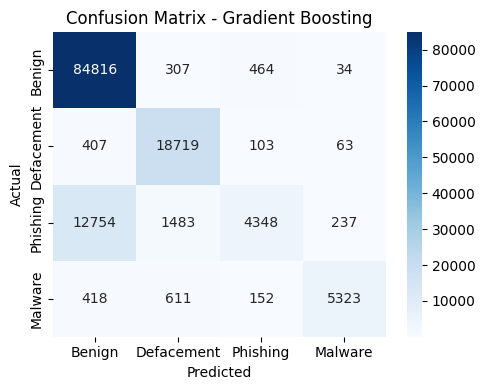

In [16]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit (X_train, y_train)
y_pred_gb = gb.predict(X_test)
result.append(evaluate_model("Gradient Boosting", y_test, y_pred_gb))

## **12. XGBoost**


XGBoost
Accuracy     : 90.34%
F1-weighted  : 88.90% 
F1-macro     : 85.19%
Precision-macro: 92.32%
Recall-macro   : 82.59%

              precision    recall  f1-score   support

      Benign       0.89      0.99      0.94     85621
  Defacement       0.93      0.99      0.96     19292
    Phishing       0.89      0.42      0.57     18822
     Malware       0.97      0.91      0.94      6504

    accuracy                           0.90    130239
   macro avg       0.92      0.83      0.85    130239
weighted avg       0.90      0.90      0.89    130239



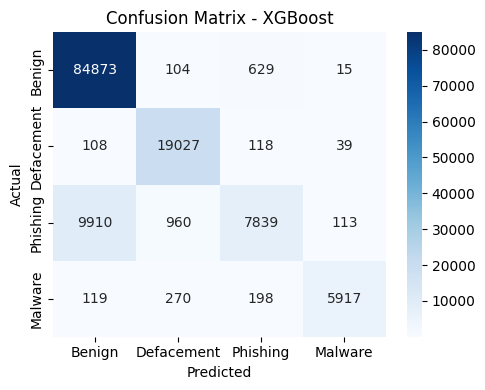

In [17]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100, random_state=42,eval_metric='mlogloss' )
xgb.fit (X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
result.append(evaluate_model("XGBoost", y_test, y_pred_xgb))

## 11. So Sánh Tổng Hợp 7 Mô Hình

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def get_metrics(name, y_test, y_pred):
    return {
        'Mô hình': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    }
results = [
    get_metrics('KNN', y_test, y_pred_knn),
    get_metrics('Naive Bayes', y_test, y_pred_nb),
    get_metrics('Decision Tree', y_test, y_pred_dt),
    get_metrics('SVM', y_test, y_pred_svm),
    get_metrics('Logistic Regression', y_test, y_pred_log_reg),
    get_metrics('Neural Network (MLP)', y_test, y_pred_mlp),
    get_metrics('Random Forest', y_test, y_pred_rf),
    get_metrics('AdaBoost', y_test, y_pred_ada),
    get_metrics('Gradient Boosting', y_test, y_pred_gb),
    get_metrics('XGBoost', y_test, y_pred_xgb)

]
df_results = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
df_results.index += 1

df_display = df_results.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    df_display[col] = df_display[col].apply(lambda x: f"{x*100:.2f}%")

print("=== BẢNG SO SÁNH TỔNG HỢP 10 MÔ HÌNH ===")
print(df_display.to_string())

=== BẢNG SO SÁNH TỔNG HỢP 10 MÔ HÌNH ===
                 Mô hình Accuracy Precision  Recall F1-Score
1          Random Forest   92.63%    92.29%  92.63%   92.26%
2   Neural Network (MLP)   92.39%    92.09%  92.39%   91.88%
3                    KNN   91.48%    91.06%  91.48%   91.14%
4                XGBoost   90.34%    90.32%  90.34%   88.90%
5          Decision Tree   87.27%    86.90%  87.27%   84.87%
6      Gradient Boosting   86.92%    86.90%  86.92%   83.96%
7    Logistic Regression   84.78%    83.75%  84.78%   80.90%
8            Naive Bayes   80.48%    79.03%  80.48%   76.16%
9               AdaBoost   78.52%    75.13%  78.52%   75.89%
10                   SVM   36.77%    76.97%  36.77%   38.45%


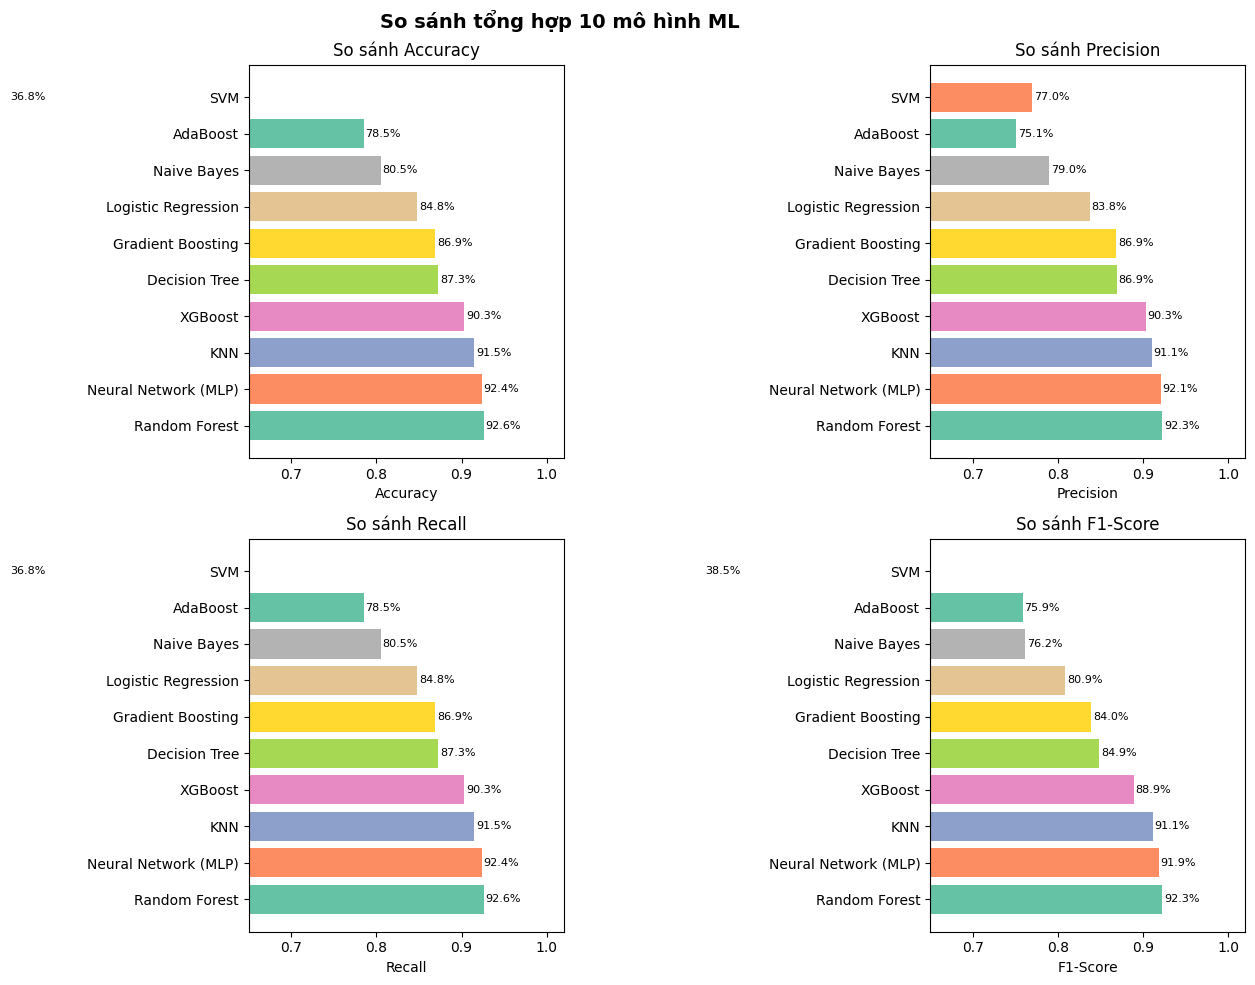

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = plt.cm.Set2.colors[:8]

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2][idx % 2]
    bars = ax.barh(df_results['Mô hình'], df_results[metric], color=colors)
    ax.set_xlabel(metric)
    ax.set_title(f'So sánh {metric}')
    ax.set_xlim(0.65, 1.02)
    for bar, v in zip(bars, df_results[metric]):
        ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
                f'{v*100:.1f}%', va='center', fontsize=8)

plt.suptitle('So sánh tổng hợp 10 mô hình ML', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()